## 📋 Executive Summary
This analysis identifies key drivers of customer churn for Telco and provides a predictive model to mitigate revenue loss.

Primary Insight: Customers on Month-to-Month contracts with High Monthly Charges (>$65) are at the highest risk, with a churn rate of 68.2% (2.6x the average).

Model Performance: Developed a Logistic Regression model with 82% accuracy, successfully identifying 60% of potential churners.

Business Goal: Transition high-risk users to long-term contracts through targeted loyalty incentives.

# 📊 Customer Churn Analysis & Prediction

## 📌 Project Overview

Customer churn is one of the biggest challenges faced by subscription-based businesses. Understanding why customers leave can help companies improve retention strategies and reduce revenue loss.

This project analyzes customer churn behavior using SQL, exploratory data analysis (EDA), data visualization, and machine learning techniques. The goal is to identify key factors influencing churn and build a predictive model capable of identifying customers at risk of leaving.

---

## 🎯 Objectives

- Perform data cleaning and preprocessing
- Analyze customer churn patterns using SQL and EDA
- Visualize relationships between customer attributes and churn
- Build a machine learning model to predict customer churn
- Generate business insights to support customer retention strategies

---

## 🛠 Tools & Technologies

- Python
- Pandas
- SQLite
- Seaborn & Matplotlib
- Scikit-learn
- Jupyter Notebook

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sklearn

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (12, 6)

print("Environment Setup Complete.")

Environment Setup Complete.


## 📥 Data Loading

The Telco Customer Churn dataset is loaded into a Pandas DataFrame to begin the analysis process.

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Data Quality Assurance

We validate dataset integrity by checking for missing values, duplicates, and overall structure before analysis.

In [3]:
health_check = {
    "Total Records": len(df),
    "Missing Values": df.isnull().sum().sum(),
    "Duplicate Rows": df.duplicated().sum(),
}

health_df = pd.DataFrame(list(health_check.items()), columns=["Metric", "Value"])
health_df

,Metric,Value
0,Total Records,7043
1,Missing Values,0
2,Duplicate Rows,0


## 🧹 Data Cleaning

The dataset was cleaned by handling missing values, converting data types, and preparing it for analysis. Invalid values in TotalCharges were converted and null rows were removed to ensure data consistency.

In [4]:
# 1. Fix names
df.columns = df.columns.str.strip().str.capitalize()

# 2. Drop the ID
df = df.drop(columns=['Customerid'])

# 3. Fix the 'Totalcharges' (Notice the lowercase 'c')
df['Totalcharges'] = pd.to_numeric(df['Totalcharges'], errors='coerce')
df['Totalcharges'] = df['Totalcharges'].fillna(df['Totalcharges'].median())

# 4. Change Churn to numbers
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 5. Final check
print("Cleaning Complete. Final Shape:", df.shape)

Cleaning Complete. Final Shape: (7043, 20)


In [5]:
df.to_csv("cleaned_data.csv")

# 🗄️ SQL-Based Business Analysis

The cleaned dataset is loaded into a SQLite database to perform SQL-based analysis and answer important customer churn business questions.

In [6]:
# Create SQLite connection
conn = sqlite3.connect('customer_churn.db')

# Load dataframe into SQL Table (The 'replace' logic works best if we clear the cache)
df.to_sql('Churn_data', conn, if_exists='replace', index=False)

# IMPORTANT: Define the function in the SAME cell to ensure it is always available
def run_query(query):
    return pd.read_sql(query, conn)

print("Dataset loaded and run_query function defined!")

Dataset loaded and run_query function defined!


## 📊 Churn Rate by Contract Type

This query identifies which contract types experience the highest customer churn rates.

In [7]:
run_query("""
SELECT Contract, 
       COUNT(*) AS Total_Customers, 
       SUM(Churn) AS Churned_Customers, 
       ROUND(AVG(Churn) * 100, 2) AS Churn_Rate 
FROM Churn_data 
GROUP BY Contract 
ORDER BY Churn_Rate DESC;
""")

,Contract,Total_Customers,Churned_Customers,Churn_Rate
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83


### 📌 Insight

Customers with month-to-month contracts show the highest churn rate (42.71%) compared to long-term contract customers. This suggests that contract length plays a significant role in customer retention.

## 💰 Average Monthly Charges by Churn Status

This query compares average monthly charges between churned and retained customers.

In [8]:
run_query("""
SELECT Churn, ROUND(AVG(Monthlycharges), 2) AS
Avg_Monthly_Charges
FROM churn_data
GROUP BY Churn""")

,Churn,Avg_Monthly_Charges
0,0,61.27
1,1,74.44


### 📌 Insight

Customers who churn tend to have higher average monthly charges, indicating that pricing may influence customer dissatisfaction and retention.

## ⏳ Average Tenure by Churn Status

This query compares customer tenure between churned and retained customers.

In [9]:
run_query("""
SELECT Churn, ROUND(AVG(Tenure),2) AS Avg_Tenure
FROM churn_data
GROUP BY Churn
""")

,Churn,Avg_Tenure
0,0,37.57
1,1,17.98


### 📌 Insight

Churned customers generally have lower average tenure than retained customers, showing that newer customers are more likely to leave the service.

## 📊 Exploratory Data Analysis (EDA)

In this section, we analyze the dataset to identify patterns, relationships, and key factors affecting customer churn.

## Churn Distribution

This analysis examines how many customers have churned versus retained

,Count,Percentage
Churn,,
Stayed,5174,73.46%
Churned,1869,26.54%


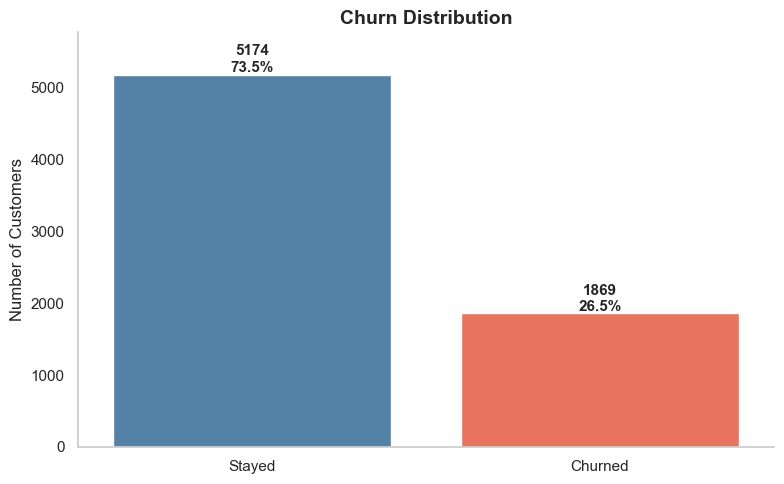

In [10]:
# ── Pandas Analysis ──────────────────────────────────────

churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%'

# Construct a summary table for quick reference
churn_summary = pd.DataFrame({
    'Count'      : churn_counts,
    'Percentage' : churn_pct
})

# Map binary values (0, 1) to human-readable

churn_summary.index = churn_summary.index.map({0:'Stayed', 1:'Churned'})
display(churn_summary)


# ── Visualization ─────────────────────────────────────────

plt.figure(figsize=(8, 5))
# Using a clear color palette
ax = sns.countplot(x='Churn', data=df,
                   palette=['steelblue', 'tomato'])

# removing grid - lines
sns.despine()
ax.yaxis.grid(False)

# overlay exact counts and percentages on top of each bar
for p in ax.patches:
    count = int(p.get_height())
    pct = f'{count/len(df)*100:.1f}%'
    ax.text(p.get_x() + p.get_width()/2,
            p.get_height() * 1.01,
            f'{count}\n{pct}',
            ha='center', fontsize=11, fontweight='bold')

# labels and title for clarity
plt.title('Churn Distribution', fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['Stayed', 'Churned'])
plt.ylabel('Number of Customers')
plt.xlabel("")
plt.ylim(0, df['Churn'].value_counts().max() + 600)
plt.tight_layout()
# Exporting chart as image
plt.savefig('01_churn_distribution.png', dpi=150)
plt.show()

### 📌 Insight: Churn Distribution
Observation: Approximately 26.5% of customers have churned, while the majority remain.

Significance: This indicates a significant retention challenge. The company should prioritize identifying high-risk segments to protect total revenue.

## 📊 Contract Type vs Churn

This analysis explores how contract type affects customer churn.

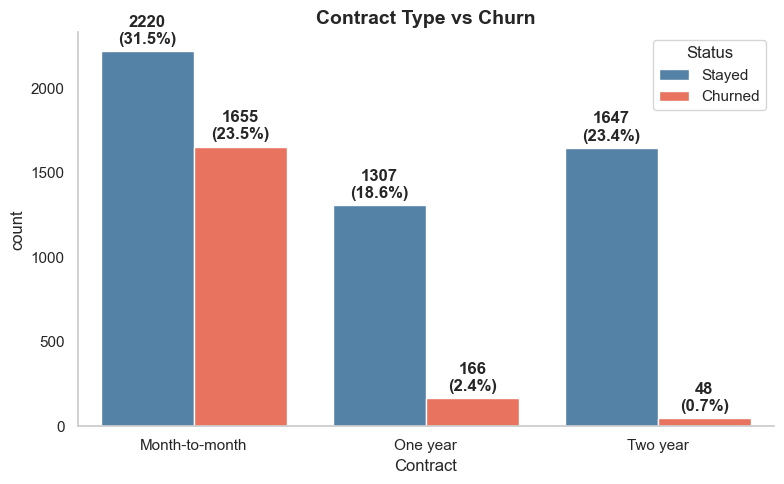

In [11]:
# ── Pandas Analysis ──────────────────────────────────────


# 1. Create the counts table
counts_raw = pd.crosstab(df['Contract'], df['Churn'])
counts_raw = counts_raw.rename(columns={0: 'Stayed_Count', 1: 'Churned_Count'})

# Create the percentage table
pcts= pd.crosstab(df['Contract'], df['Churn'], normalize='index').mul(100).round(2).astype(str) + '%'
pcts= pcts.rename(columns ={0: 'Stayed_%', 1: 'Churned_%'})

# Combine them side-by-side
contract_analysis = pd.concat([counts_raw, pcts], axis=1)

# final result
contract_analysis

# ── Visualization ─────────────────────────────────────────


plt.figure(figsize=(8,5))

# Using color palette
ax= sns.countplot(x='Contract', hue='Churn', data=df, palette=['steelblue', 'tomato'])
sns.despine()
ax.yaxis.grid(False)

# 1. Loop through each group of bars (Stayed group, then Churned group)
for container in ax.containers:
    
    # 2. Create a fresh list of labels for THIS specific group
    labels = []
    
    for bar in container:
        # Get the height of the current bar
        height = bar.get_height()
        
        # Calculate percentage (relative to total dataset)
        percentage = (height / len(df)) * 100
        
        # Create the text: "Count (Percent%)"
        # \n puts the percentage on a new line so it stays inside the bar width
        label = f'{height:.0f}\n({percentage:.1f}%)'
        
        labels.append(label)
    
    # 3. Apply the labels to the current group
    ax.bar_label(container, labels=labels, padding=3, fontweight='bold')


plt.legend(title='Status', labels=['Stayed', 'Churned'])
plt.title('Contract Type vs Churn', fontsize=14, fontweight = 'bold')
plt.tight_layout()
# Exporting chart as image
plt.savefig('02_contract_type_vs_churn.png', dpi=150)
plt.show()

### 📌 Insight: Contract Type vs Churn
Observation: Customers with Month-to-month contracts have significantly higher churn rates compared to those on one-year or two-year plans.

Significance: Long-term contracts are a powerful tool for stability. Reducing the friction of moving from monthly to yearly plans could drastically reduce churn risk.

## 📊 Monthly Charges vs Churn

This analysis explores whether higher monthly charges are associated with increased customer churn.

,Avg Monthly Charges
Churn,
Stayed,61.265124
Churned,74.441332


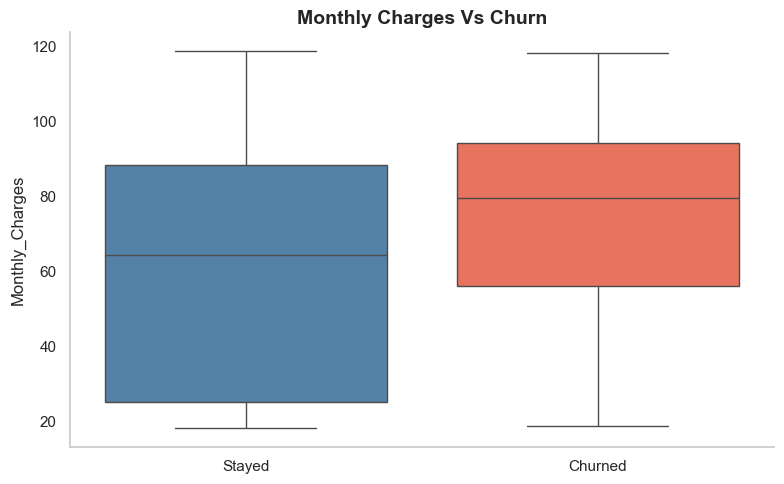

In [12]:
# ── Pandas Analysis ──────────────────────────────────────
Mon = df.groupby('Churn')['Monthlycharges'].mean()
display(Mon.rename(index={0:'Stayed', 1:'Churned'}).to_frame('Avg Monthly Charges'))

# ── Visualization ─────────────────────────────────────────

plt.figure(figsize=(8,5))

#using color palette
ax = sns.boxplot(x='Churn', y='Monthlycharges', data=df , palette=['steelblue', 'tomato'])

# Removinng gridlines from chart
sns.despine()
ax.yaxis.grid(False)

plt.title("Monthly Charges Vs Churn", fontsize=14, fontweight='bold')
plt.ylabel("Monthly_Charges")
plt.xlabel("")

# Renaming xsticks
plt.xticks([0, 1], ['Stayed', 'Churned'])

plt.tight_layout()
# Exporting chart as image
plt.savefig('03_Monthly charges_VS_churn.png', dpi=150)
plt.show()

### 📌 Insight: Monthly Charges vs Churn
Observation: Customers with higher monthly charges tend to churn more frequently.

Significance: This suggests that pricing is a major driver of dissatisfaction. High-value customers are the most sensitive to "bill shock" and competitor pricing.

## 📊 Tenure vs Churn

This analysis examines whether customer tenure influences churn behavior.

Churn
0    37.569965
1    17.979133
Name: Tenure, dtype: float64

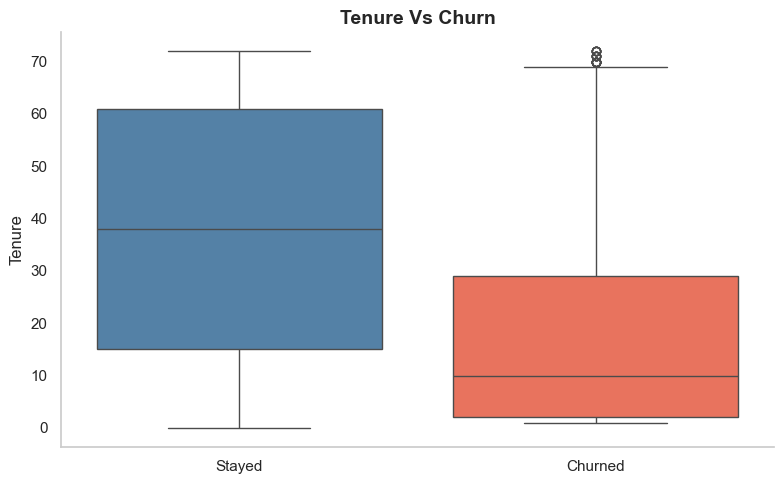

In [13]:
# ── Pandas Analysis ──────────────────────────────────────

tenure_summary = df.groupby('Churn')['Tenure'].mean()
display(tenure_summary)

# ── Visualization ─────────────────────────────────────────

plt.figure(figsize=(8,5))

#using color palette
ax = sns.boxplot(x='Churn', y='Tenure', data = df, palette=['steelblue', 'tomato'])

# Removing grid-lines from chart
sns.despine()
ax.yaxis.grid(False)

plt.title("Tenure Vs Churn", fontsize=14, fontweight = 'bold')

# Renaming xsticks
plt.xticks([0,1], ['Stayed', 'Churned'])

# x and y label naming
plt.xlabel("")
plt.ylabel("Tenure")
plt.tight_layout()
# Exporting chart as image
plt.savefig('04_Tenure_VS_churn.png', dpi=150)
plt.show()

### 📌 Insight: Tenure vs Churn
Observation: Customers with shorter tenure (specifically under 18 months) are much more likely to churn than long-term customers.

Significance: Retention efforts are most critical during the "early lifecycle." Improving engagement in the first 12 months is key to building long-term loyalty.

## 📊 Internet Service vs Churn

This analysis explores whether the type of internet service 
a customer uses influences their likelihood to churn.

,Churn Rate %
Internetservice,
DSL,18.96
Fiber optic,41.89
No,7.40


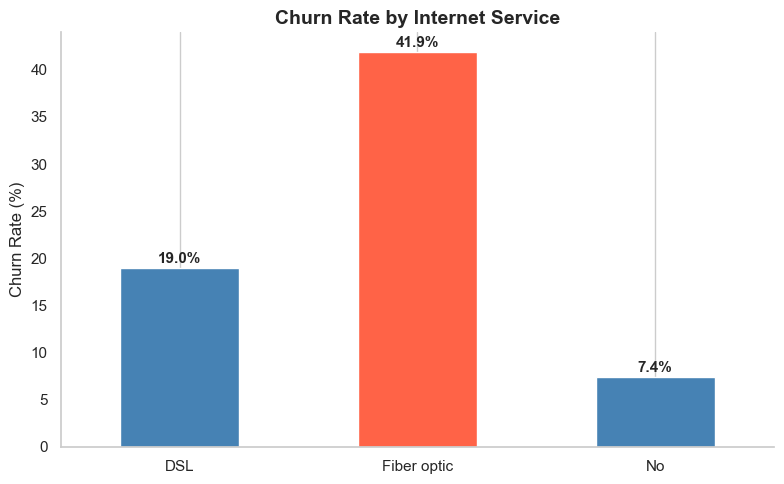

In [14]:
# ── Pandas Analysis ──────────────────────────────────────
# Calculate churn percentage per internet service type
internet = df.groupby('Internetservice')['Churn'].mean().mul(100).round(2)
display(internet.to_frame('Churn Rate %'))

# ── Visualization ─────────────────────────────────────────
plt.figure(figsize=(8, 5))
# Plot churn rates with specific color highlights
ax = internet.plot(kind='bar', color=['steelblue', 'tomato', 'steelblue'], edgecolor='white')

# Clean chart aesthetics
sns.despine()
ax.yaxis.grid(False)

# Add percentage labels on top of bars
for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2, p.get_height() + 0.5, f'{p.get_height():.1f}%', 
            ha='center', fontsize=11, fontweight='bold')

# Formatting labels and title
plt.title('Churn Rate by Internet Service', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.xlabel('')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()

# Save and display
plt.savefig('05_internet_service_vs_churn.png', dpi=150)
plt.show()

### 📌 Insight: Internet Service vs Churn

**Observation:** Fiber optic customers churn at a significantly 
higher rate (42%) compared to DSL customers (19%) and 
customers with no internet service (7%).

**Significance:** Fiber optic is the premium, higher-cost service. 
This suggests that high-paying customers feel the most pressure 
from pricing or unmet expectations — exactly the customers the 
business can least afford to lose.

## 🚨 High Risk Segment Identification

Combining the three strongest churn signals found in our analysis:
- Month-to-month contract
- Tenure under 12 months (new customer)
- Monthly charges above $65 (high paying)

This identifies the most vulnerable customer group in the dataset.

In [15]:
high_risk = df[
    (df['Contract'] == 'Month-to-month') &
    (df['Tenure'] < 12) &
    (df['Monthlycharges'] > 65)
]

print(f"High Risk Segment     : {len(high_risk)} customers")
print(f"Segment Churn Rate    : {high_risk['Churn'].mean()*100:.1f}%")
print(f"Overall Churn Rate    : {df['Churn'].mean()*100:.1f}%")
print(f"Risk Multiplier       : {high_risk['Churn'].mean()/df['Churn'].mean():.1f}x higher")

High Risk Segment     : 931 customers
Segment Churn Rate    : 68.2%
Overall Churn Rate    : 26.5%
Risk Multiplier       : 2.6x higher


## 📌 Insight: High-Risk Segment Identification
Observation: Customers with month-to-month contracts, tenure < 12 months, and monthly charges > $65 exhibit a 68.2% churn rate.

Significance: This group is 2.6x more likely to churn than the average customer. They represent a "Perfect Storm" of high cost and low commitment, leading to significant revenue leakage shortly after acquisition.

# 🤖 Predictive Modeling

After completing exploratory data analysis (EDA), a machine learning model is built to predict customer churn based on customer demographics, account information, and service usage patterns.

The objective of this section is to identify customers who are likely to churn, helping businesses improve retention strategies and customer satisfaction.

In [16]:
# Bring in a tool to split our data into training and testing

from sklearn.model_selection import train_test_split

# Import the actual Logistic Regression algorithm

from sklearn.linear_model import LogisticRegression

#Import a tool to calculate the 'Accuracy Score'

from sklearn.metrics import accuracy_score

# Import the Confusion Matrix tool

from sklearn.metrics import confusion_matrix

## 🔄 Data Encoding

Machine learning models require numerical input data. In this step, categorical variables are converted into numeric format using one-hot encoding.

In [17]:
df_encoded = pd.get_dummies(df, drop_first=True)

x = df_encoded.drop('Churn', axis=1)

y = df_encoded['Churn']

## ✂️ Train-Test Split

The dataset is divided into training and testing sets. The training set is used to train the model, while the testing set evaluates model performance on unseen data.

In [18]:
x_train, x_test, y_train, y_test = train_test_split(
    x,y,test_size=0.2,random_state=42
)

## 🤖 Logistic Regression Model

A Logistic Regression model is trained to classify whether a customer is likely to churn or remain with the company.

In [19]:
model = LogisticRegression(max_iter=1000)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

## 📊 Model Evaluation

The trained model is evaluated using accuracy score and confusion matrix to measure prediction performance and identify classification errors.

In [20]:
accuracy =  accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.0%}")

Model Accuracy: 82%


In [21]:
cm = confusion_matrix(y_test, y_pred)

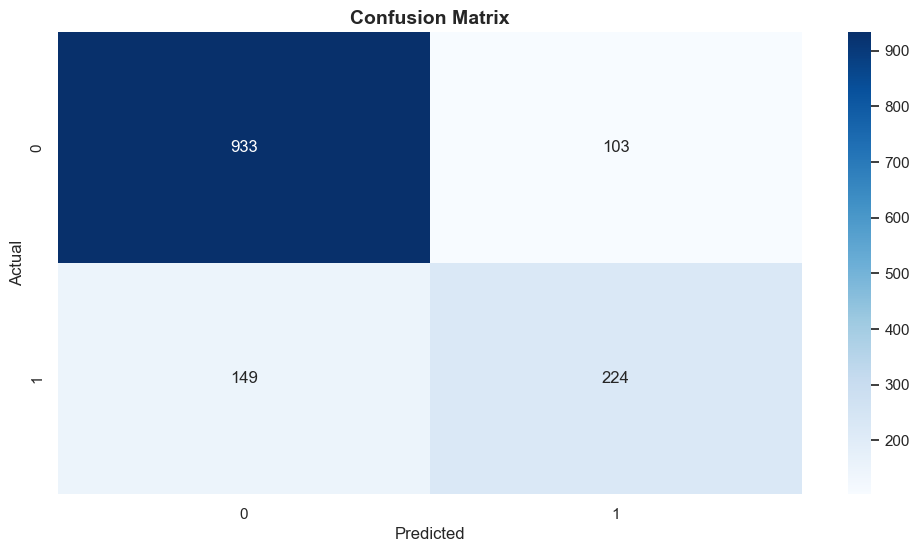

In [22]:
sns.heatmap(cm, annot=True, fmt='d',cmap='Blues')
plt.title("Confusion Matrix", fontsize=14, fontweight='bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")
# Exporting chart as image
plt.savefig('06_confusion_matrix.png', dpi=150)
plt.show()

## 📌 Insight: Model Performance (Confusion Matrix)

The confusion matrix allows us to look beyond simple accuracy and see exactly where our model is making mistakes.

| Metric | Value | Business Interpretation |
| :--- | :--- | :--- |
| **True Negatives** | **933** | **Correctly identified loyal customers.** The model is very good at spotting people who will stay. |
| **True Positives** | **224** | **Correctly caught churners.** We identified 224 customers who were going to leave so we can act. |
| **False Negatives** | **149** | **Missed Alarms.** These customers churned, but the model didn't see it coming. This is our biggest risk area. |
| **False Positives** | **103** | **False Alarms.** These customers were predicted to leave but stayed. Giving them a discount is a minor cost. |

### 🔍 Analysis:
* **Accuracy (~82%):** On the surface, the model looks strong. 
* **The Churn Gap:** We are successfully catching roughly **60%**
* **Business Strategy:** Since **False Negatives (149)** are more expensive than **False Positives (103)**, improving churn detection should be priortized to reduce customer loss

# ✅ Conclusion

This project explored customer churn behavior using SQL analysis, exploratory data analysis (EDA), data visualization, and machine learning techniques.

Key findings revealed that customers with higher monthly charges, shorter tenure, and month-to-month contracts are more likely to churn. A Logistic Regression model was also developed to predict churn behavior and evaluate customer retention risk.

The project demonstrates an end-to-end data analytics workflow including:
- Data cleaning and preprocessing
- SQL-based business analysis
- Data visualization and insight generation
- Machine learning model development
- Business-focused interpretation of results

These insights can help businesses improve customer retention strategies and reduce potential revenue loss.